# Setting Variables
Hubble constant:
$$H_0=100h\text{ km s}^{-1} \text{ Mpc}^{-1} $$
1 Mpc:
$$1Mpc = 3.26 \times 10^6\text{ ly} = 3.09 \times 10^{19}\text{ km}$$
Little h:
$$h=7/10$$
Current void fraction of the universe:
$$f_{v0}=0.76$$
Current wall fraction of the universe:
$$1-f_{v0}=0.24$$
Bare Hubble Constant:
$$\overset{-}{H}_0=\frac{2H_0(2+f_{v0})}{(4f_{v0}^2+f_{v0}+4)}\text{ With units of}\text{ km s}^{-1} \text{ Mpc}^{-1}$$
Present dressed matter density:
$$\Omega_{M0}=\frac{1}{2}(1-f_{v0})(2+f_{v0})$$

In [ ]:
import numpy as np
h              = 7/10        # Unitless
H_0            = 100 * h     # km s^-1 Mpc^-1
f_v0           = 0.76        # Unitless
f_w0           = 0.24        # Unitless
Mpc            = 3.09e19     # km
bare_H_0       = (2 * H_0 * (2 + f_v0))/(4 * f_v0 ** 2 + f_v0 + 4) # km s^-1 Mpc^-1
omega_m0 = 0.5 * (1-f_v0)*(2+f_v0)
year = 60 * 60 * 24 * 365.25 # s
gyr = 10**9 * year           # Billion years
print(f'Bare Hubble Constant   = {bare_H_0:.2f} km s^-1 Mpc^-1')
print(f'Dressed matter density = {omega_m0:.2f}')

Bare Hubble Constant   = 54.65 km s^-1 Mpc^-1
Dressed matter density = 0.33


Age of the universe in wall time:
$$\tau_0=\frac{2(2+f_{v0})}{9\overset{-}{H}_0}[1+\frac{(1-f_{v0})}{3f_{v0}}ln(\frac{2+f_{v0}}{2(1-f_{v0)})})]$$


Age of the universe in volume average time:
$$t_0=\frac{2 + f_{v0}}{3\overset{-}{H}_0}$$

Ages have units $\frac{1}{H_0}$: $\text{Mpc km}^{-1}$ s. Mpc and km are both units of distance. Multiplying by 1Mpc gives age in seconds.

Wall time $\tau$ in terms of volume average time, t:
$$\tau= \int _0^t \frac{dt}{\overset{-}{\gamma}}
     = \frac{2}{3}t+\frac{4\Omega_{M0}}{27f_{v0}\overset{-}{H}_0}ln(1+\frac{{9f_{v0}\overset{-}{H}_0t}}{4\Omega_{M0}})$$

In [39]:
wall_age = ((2 * (2+f_v0))/(9*bare_H_0)) * (1 + ((1-f_v0)/(3*f_v0)) * np.log((2+f_v0)/(2*(1-f_v0))))
wall_age_gyr = wall_age * Mpc / gyr
print(f'Wall age = {wall_age_gyr:.2f} billion years.')
vol_avg_age = (2+f_v0)/(3*bare_H_0)
vol_avg_age_gyr = vol_avg_age * Mpc / gyr
print(f'Volume average age = {vol_avg_age_gyr:.2f} billion years.')
print(f'A difference of {vol_avg_age_gyr-wall_age_gyr:.2f} billion years')

Wall age = 13.01 billion years.
Volume average age = 16.48 billion years.
A difference of 3.47 billion years


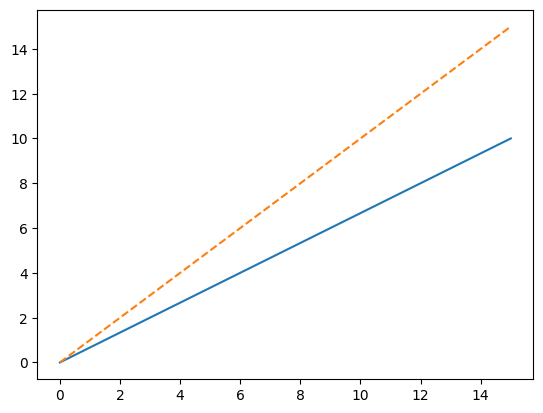

In [3]:
import matplotlib.pyplot as plt

def tau_of_t(t):
    f_v0           = 0.76        # Unitless
    omega_m0 = 0.5 * (1-f_v0)*(2+f_v0)
    bare_H_0       = (2 * H_0 * (2 + f_v0))/(4 * f_v0 ** 2 + f_v0 + 4) # km s^-1 Mpc^-1
    
    term_1 = (2/3) * t
    term_2 = (4*omega_m0)/(27 * f_v0 * bare_H_0)
    term_3 = np.log(1 + (9 * f_v0)/(4 * omega_m0))

    return term_1 + term_2 * term_3

t = np.linspace(0, 15, 1000)

tau = tau_of_t(t)

plt.plot(t, tau, label="Wall time")
plt.plot(t, t, linestyle='--')
plt.show()